In [1]:
from aeon.datasets import load_classification
from sklearn.preprocessing import LabelEncoder

X, y = load_classification("GunPoint")
y = LabelEncoder().fit_transform(y)

In [ ]:
from saxo.sklearn import SAXO

max_symbols = 5
saxo = SAXO(
    timestamp_discretization="SAXO",
    n_jobs=-1,
    max_intervals=10,
    max_symbols=max_symbols,
    refined=True,
).fit(X)

/Users/pierrenodet/Projects/saxo/.venv/lib/python3.13/site-packages/khiops/core/internals/runner.py:1043: UserWarning: Sample datasets location does not exist (/Users/pierrenodet/khiops_data/samples). Execute the kh-download-datasets script or the khiops.tools.download_datasets function to download them.
  self._initialize_default_samples_dir()


In [ ]:
X_saxo = saxo.transform(X)
X_saxo

array([['b', 'd', 'b', ..., 'b', 'a', 'b'],
       ['b', 'c', 'a', ..., 'b', 'a', 'b'],
       ['a', 'b', 'b', ..., 'a', 'd', 'b'],
       ...,
       ['a', 'b', 'b', ..., 'b', 'a', 'c'],
       ['c', 'a', 'd', ..., 'd', 'b', 'e'],
       ['c', 'a', 'e', ..., 'd', 'c', 'd']], shape=(200, 10), dtype=object)

In [ ]:
y_pred_saxo = saxo.score_samples(X)
ano_saxo = y_pred_saxo.sum(axis=1).argmin()
y_pred_saxo[ano_saxo]

array([-0.9490125 , -1.38728652, -0.89219284, -1.25571033, -0.99754554,
       -0.50120245, -0.98809832, -0.82303923, -0.997626  , -1.0588444 ])

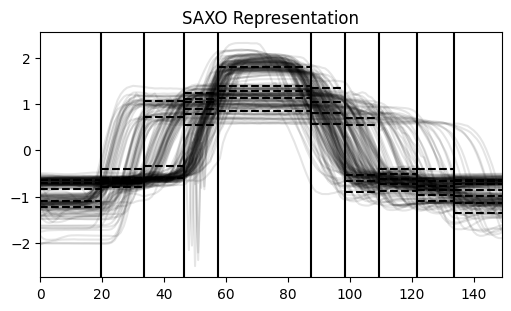

In [ ]:
from matplotlib import pyplot as plt
from saxo.viz import plot_saxo

fig, ax = plt.subplots(figsize=(5, 3), layout="constrained")
plot_saxo(saxo, [ax], X=X)
ax.plot(X[ano_saxo].T, color="red")
ax.set_xlim((0, X.shape[-1] - 1))
ax.set_title("SAXO Representation")

In [ ]:
from aeon.transformations.collection.dictionary_based import SAX

sax = SAX(n_segments=10, alphabet_size=5, n_jobs=-1).fit(X)

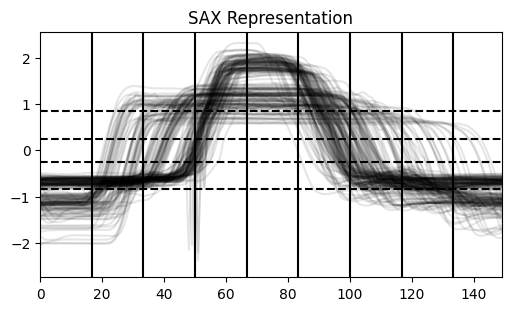

In [ ]:
import numpy as np


def plot_sax(sax: SAX, axes: list[plt.Axes], X):
    timestamp_bounds = np.linspace(0, X.shape[-1], sax.n_segments)
    value_bounds = sax.breakpoints
    if value_bounds.ndim == 1:
        value_bounds = value_bounds.reshape(1, -1)
    for i in range(1, len(timestamp_bounds) - 1):
        axes[0].axvline(timestamp_bounds[i], color="black")
    for i in range(value_bounds.shape[0]):
        axes[0].plot(
            (timestamp_bounds[0], timestamp_bounds[-1]),
            (value_bounds[i], value_bounds[i]),
            color="black",
            linestyle="--",
        )
    if X is not None:
        axes[0].plot(X[:, 0, :].T, alpha=0.1, color="black")
        axes[0].set_xlim((0, X.shape[-1] - 1))


fig, ax = plt.subplots(figsize=(5, 3), layout="constrained")
plot_sax(sax, [ax], X=X)
ax.plot(X[ano_saxo].T, color="red")
ax.set_xlim((0, X.shape[-1] - 1))
ax.set_title("SAX Representation")

In [ ]:
max_symbols = 5
tri = SAXO(
    timestamp_discretization="SAXO",
    n_jobs=-1,
    max_intervals=10,
    max_symbols=max_symbols,
    refined=False,
).fit(X)

In [ ]:
X_tri = tri.transform(X)
X_tri

array([['e', 'e', 'e', ..., 'd', 'b', 'e'],
       ['e', 'e', 'e', ..., 'd', 'b', 'e'],
       ['d', 'd', 'd', ..., 'd', 'd', 'd'],
       ...,
       ['d', 'd', 'd', ..., 'd', 'b', 'e'],
       ['a', 'a', 'a', ..., 'a', 'a', 'a'],
       ['a', 'c', 'b', ..., 'c', 'c', 'c']], shape=(200, 8), dtype=object)

In [ ]:
y_pred_tri = tri.score_samples(X)
ano_tri = y_pred_tri.sum(axis=1).argmin()
y_pred_tri[ano_tri]

array([-2.33531182, -4.16697756, -4.50027878, -3.34026626, -3.42366809,
       -5.73872041, -2.9633922 , -2.02402773])

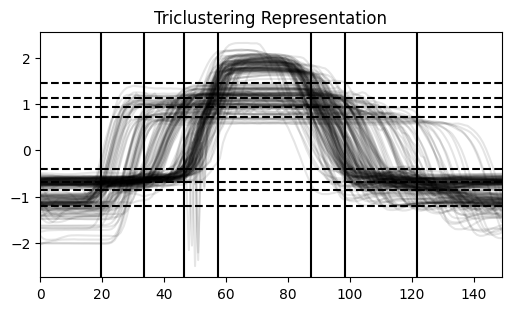

In [ ]:
from matplotlib import pyplot as plt
from saxo.viz import plot_saxo

fig, ax = plt.subplots(figsize=(5, 3), layout="constrained")
plot_saxo(tri, [ax], X=X)
ax.plot(X[ano_tri].T, color="red")
ax.set_xlim((0, X.shape[-1] - 1))
ax.set_title("Triclustering Representation")

In [ ]:
max_symbols = 5
saxo_no_tri = SAXO(
    timestamp_discretization=None,
    n_jobs=-1,
    max_intervals=10,
    max_symbols=max_symbols,
    refined=True,
).fit(X)

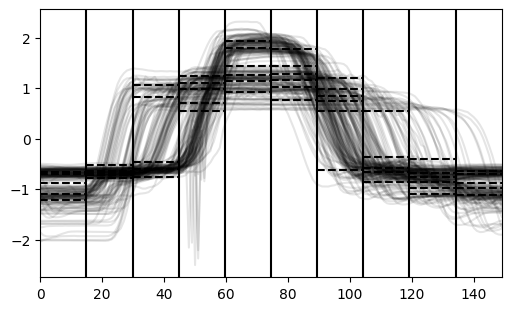

In [ ]:
fig, ax = plt.subplots(figsize=(5, 3), layout="constrained")
plot_saxo(saxo_no_tri, [ax], X=X)
ax.set_xlim((0, X.shape[-1] - 1))
plt.show()

In [ ]:
from sklearn.pipeline import FunctionTransformer, make_pipeline
from aeon.transformations.collection.dictionary_based import SAX


sax = make_pipeline(
    SAX(n_segments=10, alphabet_size=max_symbols, n_jobs=-1),
    FunctionTransformer(lambda d: d.squeeze()),
).fit(X)
X_sax = sax.transform(X)

In [16]:
from matplotlib import pyplot as plt
from scipy.spatial.distance import pdist, squareform

H_saxo = squareform(pdist(X_saxo, lambda u, v: (u != v).sum()))
H_sax = squareform(pdist(X_sax, lambda u, v: (u != v).sum()))

In [21]:
from sklearn.manifold import TSNE
from aeon.transformations.collection.convolution_based import MiniRocket
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.decomposition import PCA

seed = 2312
representations = [
    (
        "Euclidean",
        make_pipeline(PCA(n_components=10), TSNE(random_state=seed)).fit_transform(
            X.reshape(X.shape[0], -1)
        ),
    ),
    (
        "MiniRocket",
        make_pipeline(
            MiniRocket(n_kernels=1000, n_jobs=-1),
            PCA(n_components=10),
            TSNE(random_state=seed),
        ).fit_transform(X),
    ),
    (
        "SAX",
        make_pipeline(
            OrdinalEncoder(),
            PCA(n_components=10),
            TSNE(random_state=seed),
        ).fit_transform(X_sax),
    ),
    (
        "SAXO",
        make_pipeline(
            OneHotEncoder(sparse_output=False),
            PCA(n_components=10),
            TSNE(random_state=seed),
        ).fit_transform(X_saxo),
    ),
    (
        "Triclustering",
        make_pipeline(
            OneHotEncoder(sparse_output=False),
            PCA(n_components=10),
            TSNE(random_state=seed),
        ).fit_transform(X_tri),
    ),
    # (
    #     "SAX",
    #     TSNE(random_state=seed, metric="precomputed", init="random").fit_transform(
    #         H_sax
    #     ),
    # ),
    # (
    #     "SAXO",
    #     TSNE(random_state=seed, metric="precomputed", init="random").fit_transform(
    #         H_saxo
    #     ),
    # ),
]

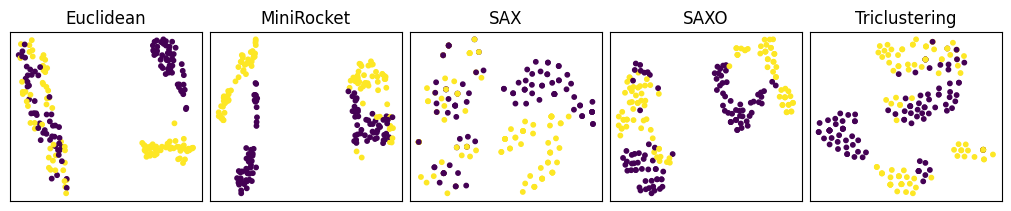

In [22]:
fig, axes = plt.subplots(
    1, len(representations), figsize=(2 * len(representations), 2), layout="constrained"
)
for i, (name, representation) in enumerate(representations):
    axes[i].scatter(
        representation[:, 0], representation[:, 1], c=y, s=10, alpha=1
    )  # , edgecolor="black",

    axes[i].set_title(name)
    axes[i].set_xticks(())
    axes[i].set_yticks(())
plt.show()

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import FunctionTransformer

clf = LogisticRegression(max_iter=1000, C=1)
tasks = [
    ("Raw", (FunctionTransformer(lambda d: d.squeeze()), X, y)),
    ("MiniRocket", (MiniRocket(n_kernels=1000, n_jobs=-1), X, y)),
    ("SAX", (OrdinalEncoder(), X_sax, y)),
    ("SAXO", (OneHotEncoder(), X_saxo, y)),
    ("Triclustering", (OneHotEncoder(), X_tri, y)),
]

for name, (pipeline, XX, yy) in tasks:
    if pipeline is not None:
        XX = pipeline.fit_transform(XX)
    results = cross_val_score(clf, XX, yy)
    print(name, results, sum(results) / len(results))

Raw [1.    0.925 0.875 0.925 0.9  ] 0.925
MiniRocket [1.    1.    1.    0.95  0.975] 0.985
SAX [0.8   0.75  0.6   0.725 0.7  ] 0.7150000000000001
SAXO [0.875 0.975 0.95  0.95  1.   ] 0.95
Triclustering [0.9   0.775 0.95  0.875 0.925] 0.885


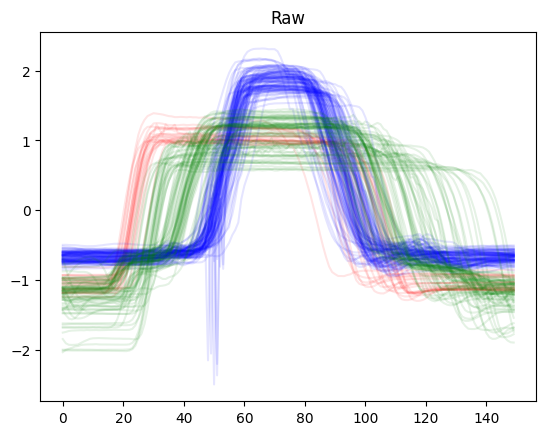

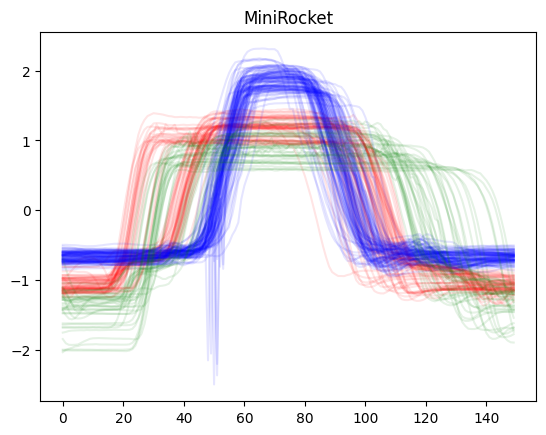

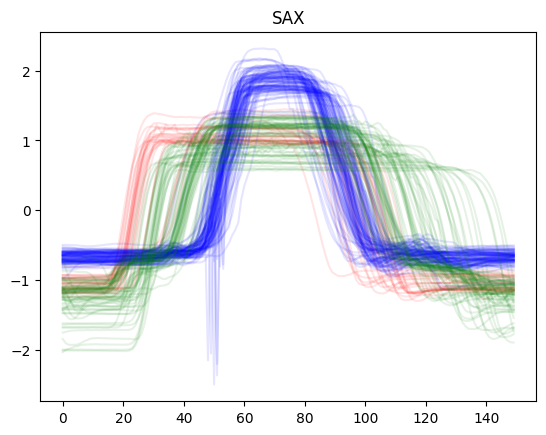

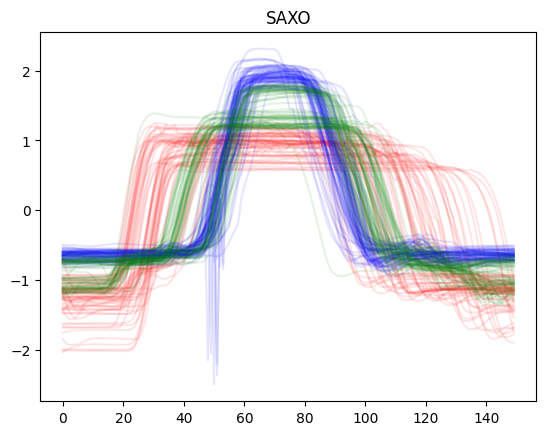

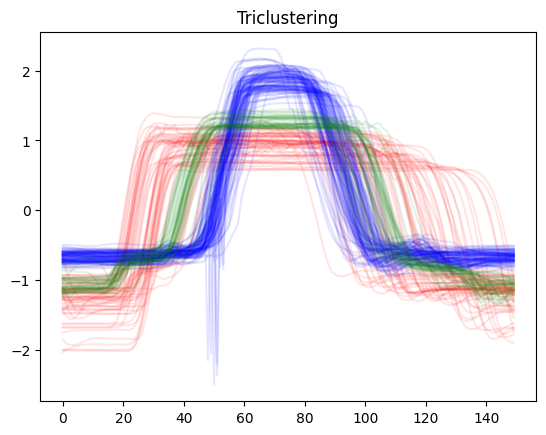

In [24]:
from sklearn.cluster import KMeans

clusters = 3
clustering = KMeans(clusters, random_state=seed)
tasks = [
    ("Raw", (FunctionTransformer(lambda d: d.squeeze()), X, y)),
    ("MiniRocket", (MiniRocket(n_kernels=1000, n_jobs=-1), X, y)),
    ("SAX", (OrdinalEncoder(), X_sax, y)),
    ("SAXO", (OneHotEncoder(), X_saxo, y)),
    ("Triclustering", (OneHotEncoder(), X_tri, y)),
]
for name, (pipeline, XX, yy) in tasks:
    if pipeline is not None:
        XX = pipeline.fit_transform(XX)
    ypyp = clustering.fit_predict(XX)
    colors = ["red", "blue", "green"]
    for i in range(clusters):
        plt.plot(X[ypyp == i].squeeze().transpose(), color=colors[i], alpha=0.1)
    plt.title(name)
    plt.show()

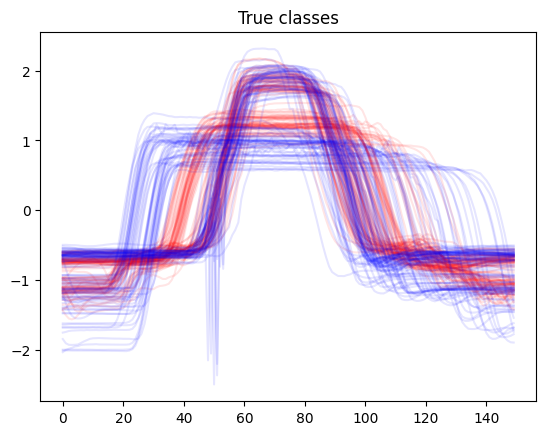

In [25]:
colors = ["red", "blue", "green"]
for i in range(2):
    plt.plot(X[yy == i].squeeze().transpose(), color=colors[i], alpha=0.1)
plt.title("True classes")
plt.show()